## Кластеризация изображений при помощи CLIP

Цель и результат
С помощью CLIP-модели разделить базу изображений на кластеры по косинусной близости отдельных картинок.

Описание
1. Открыть ноутбук hometask.ipynb в материалах
2. Дописать код в указанных местах
3. Получить кластеры и примеры изображений в этих кластерах

hometask.ipynb https://drive.google.com/file/d/12JHfi9iZ52HfLKCm4zKbHPqsNih2k_I9/view?usp=drive_link

Презентация - https://cdn.otus.ru/media/public/61/38/%D0%A2%D1%80%D0%B0%D0%BD%D1%81%D1%84%D0%BE%D1%80%D0%BC%D0%B5%D1%80%D1%8B_%D0%B2_CV_%D0%9B%D0%B5%D0%BA%D1%86%D0%B8%D1%8F-502039-6138f4.pdf

Дополнительный материал - https://habr.com/ru/companies/rwb/articles/992716/


In [1]:
!pip install sentence-transformers

In [2]:
from sentence_transformers import SentenceTransformer, util
from PIL import Image
import glob
import torch
import pickle
import zipfile
from IPython.display import display
from IPython.display import Image as IPImage
import os
from tqdm.autonotebook import tqdm

#Загружаем модель (полный список можно посмотреть тут https://huggingface.co/sentence-transformers)
model = SentenceTransformer('clip-ViT-B-32')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [3]:
# Далее, скачиваем 25 тыс. изображений с Unsplash
img_folder = 'photos/'
if not os.path.exists(img_folder) or len(os.listdir(img_folder)) == 0:
    os.makedirs(img_folder, exist_ok=True)

    photo_filename = 'unsplash-25k-photos.zip'
    if not os.path.exists(photo_filename):   # Скачиваем набор данных, если он не существует
        util.http_get('http://sbert.net/datasets/'+photo_filename, photo_filename)

    # Извлекаем все изображения
    with zipfile.ZipFile(photo_filename, 'r') as zf:
        for member in tqdm(zf.infolist(), desc='Извлечение'):
            zf.extract(member, img_folder)

In [4]:
# Получаем эмбеддинги картинок

img_names = list(glob.glob('photos/*.jpg'))
print("Images:", len(img_names))
img_emb = model.encode([Image.open(filepath) for filepath in img_names], batch_size=128, convert_to_tensor=True, show_progress_bar=True)

Images: 24996


Batches:   0%|          | 0/196 [00:00<?, ?it/s]

In [5]:
# Функция расчета косинусного расстояния и создания кластеров

def community_detection(embeddings, threshold, min_community_size=10, init_max_size=1000):
    """
    Функция для быстрого обнаружения кластеров.

    Возвращает только те кластеры, которые больше, чем min_community_size. Кластеры возвращаются
    в порядке убывания. Первый элемент в каждом кластере - центральная точка кластера.
    """

    # Вычисляем оценки косинусной схожести (посмотрите на функцию cos_sim из util)
    cos_scores = util.cos_sim(embeddings, embeddings)

    # Минимальный размер кластера
    top_k_values, _ = cos_scores.topk(k=min_community_size, largest=True)

    # Фильтрация  с значениями >= min_threshold
    extracted_communities = []
    for i in range(len(top_k_values)):
        if top_k_values[i][-1] >= threshold:
            new_cluster = []

            # Проверяем только init_max_size самых похожих элементов (быстрее, чем весь ряд)
            top_val_large, top_idx_large = cos_scores[i].topk(k=min(init_max_size, len(cos_scores[i])), largest=True)
            top_idx_large = top_idx_large.tolist()
            top_val_large = top_val_large.tolist()

            if top_val_large[-1] < threshold:
                for idx, val in zip(top_idx_large, top_val_large):
                    if val < threshold:
                        break
                    new_cluster.append(idx)
            else:
                # Проверяем весь ряд целиком (медленнее)
                for idx, val in enumerate(cos_scores[i].tolist()):
                    if val >= threshold:
                        new_cluster.append(idx)

            extracted_communities.append(new_cluster)

    # Сортируем: самые большие кластеры в начале
    extracted_communities = sorted(extracted_communities, key=lambda x: len(x), reverse=True)

    # Удаляем кластеры, элементы которых уже вошли в более крупный кластер
    unique_communities = []
    extracted_ids = set()

    for community in extracted_communities:
        add_cluster = True
        for idx in community:
            if idx in extracted_ids:
                add_cluster = False
                break

        if add_cluster:
            unique_communities.append(community)
            for idx in community:
                extracted_ids.add(idx)

    return unique_communities

In [6]:
# Теперь запускаем алгоритм кластеризации
# С параметром threshold мы определяем, при каком пороге мы идентифицируем
# два изображения как похожие. Установите порог ниже, и вы получите более крупные кластеры, в которых
# изображения менее похожи.
# С параметром min_community_size мы определяем, что мы хотим иметь только кластеры определенного минимального размера

clusters = community_detection(img_emb, threshold=0.9, min_community_size=10, init_max_size=1000)
print("Общее количество кластеров:", len(clusters))

Общее количество кластеров: 153



Размер кластера: 512


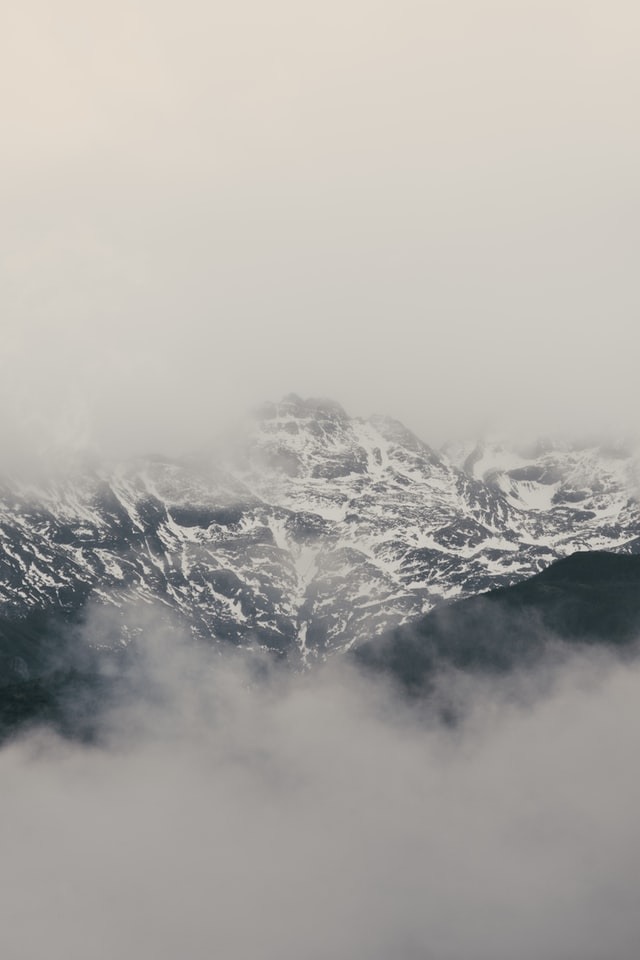

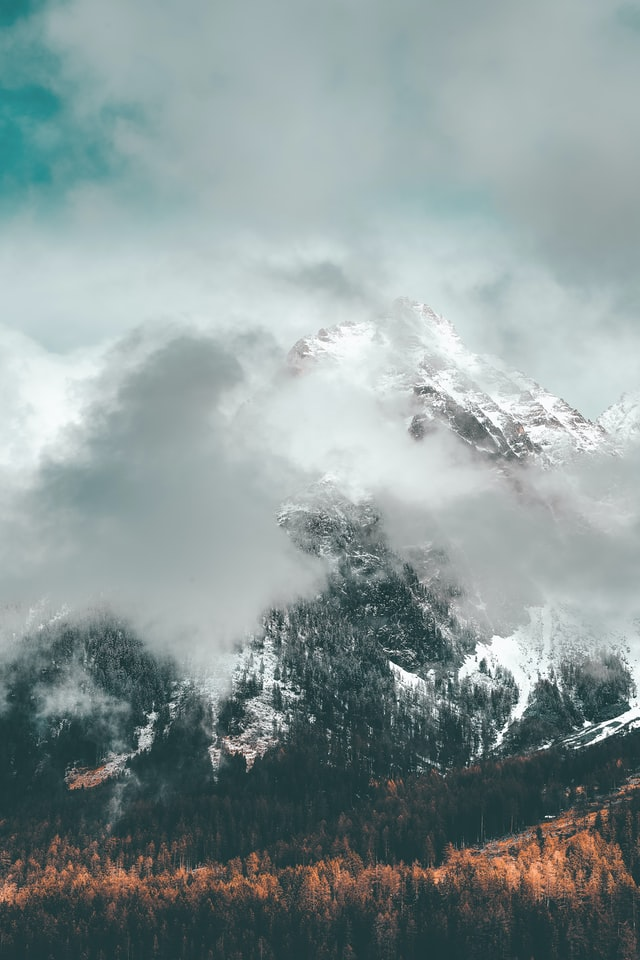

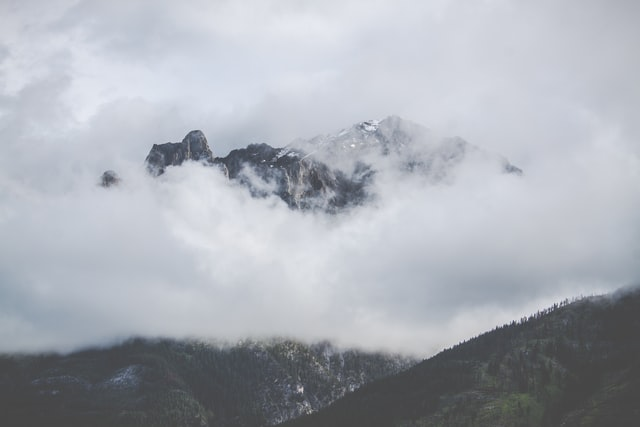


Размер кластера: 426


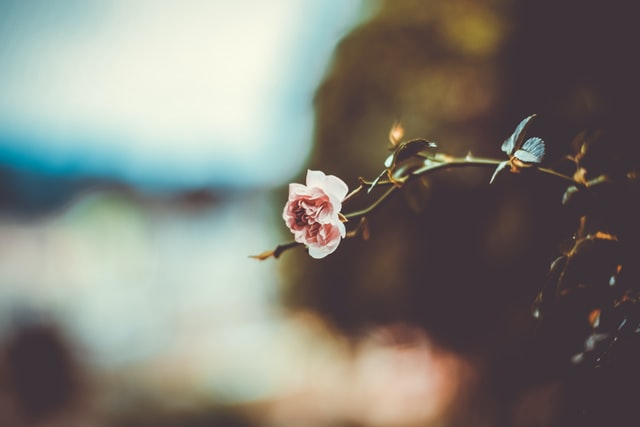

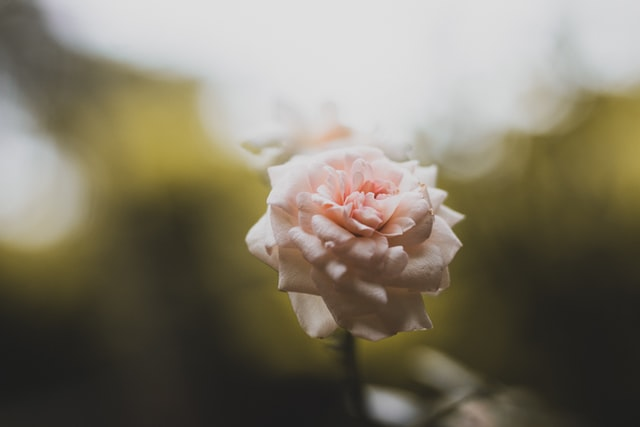

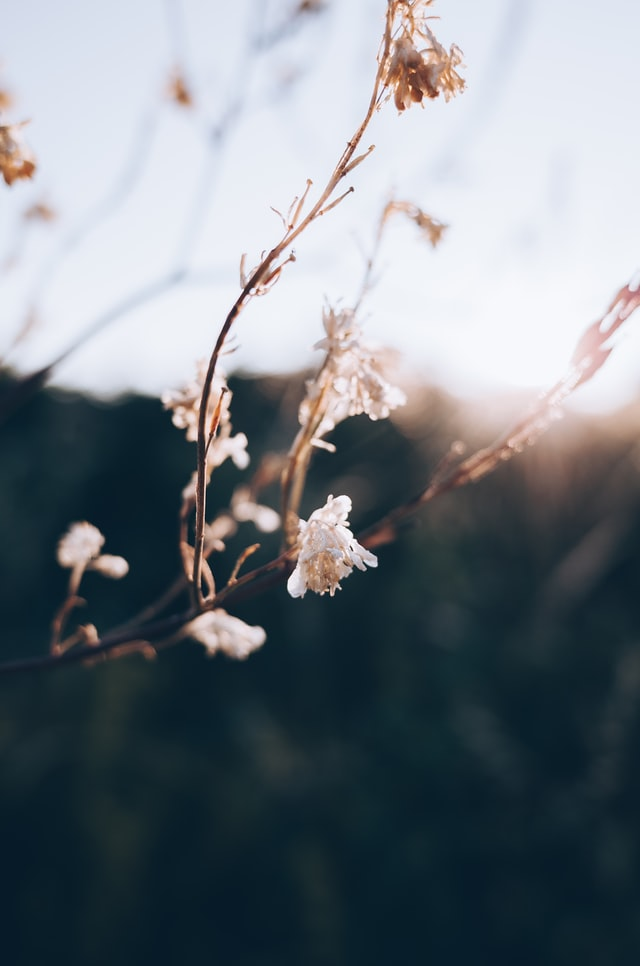


Размер кластера: 383


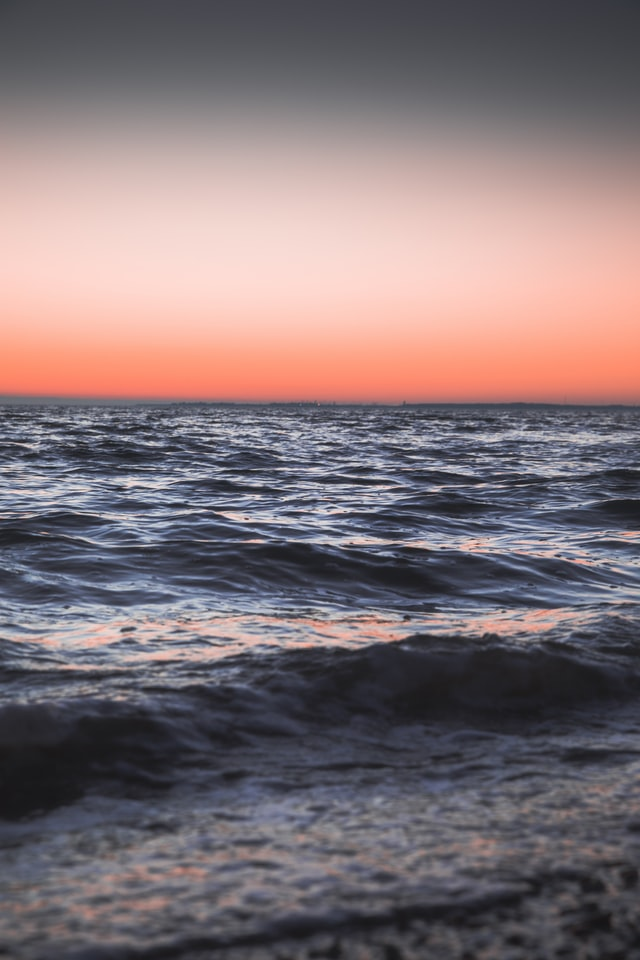

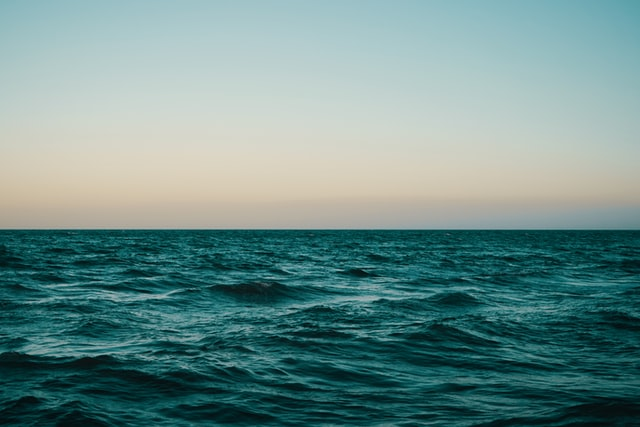

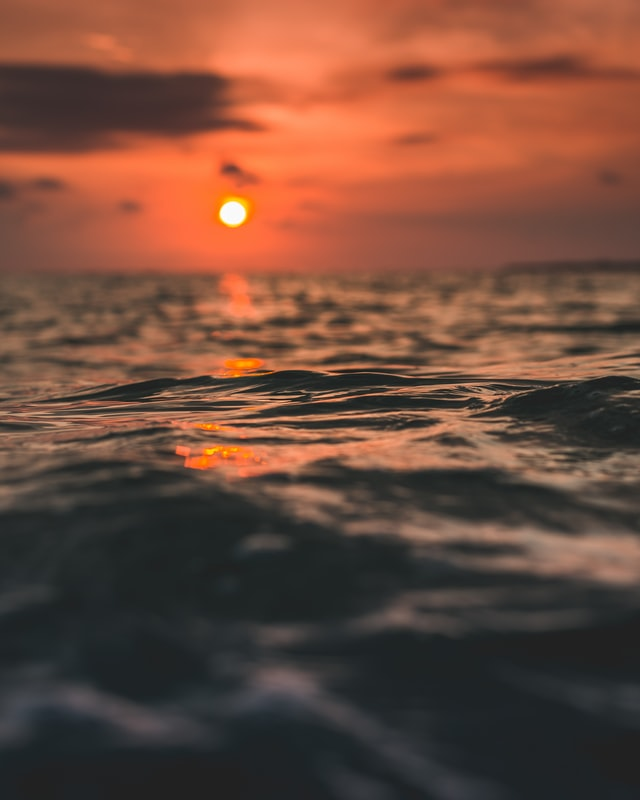


Размер кластера: 273


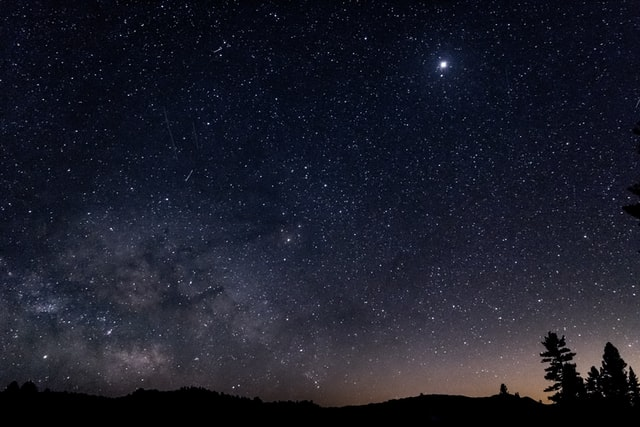

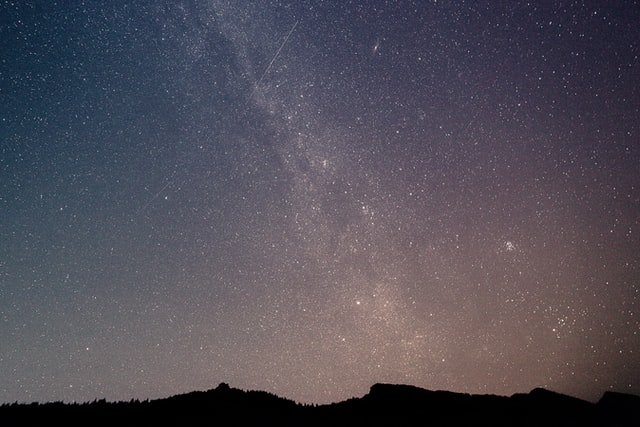

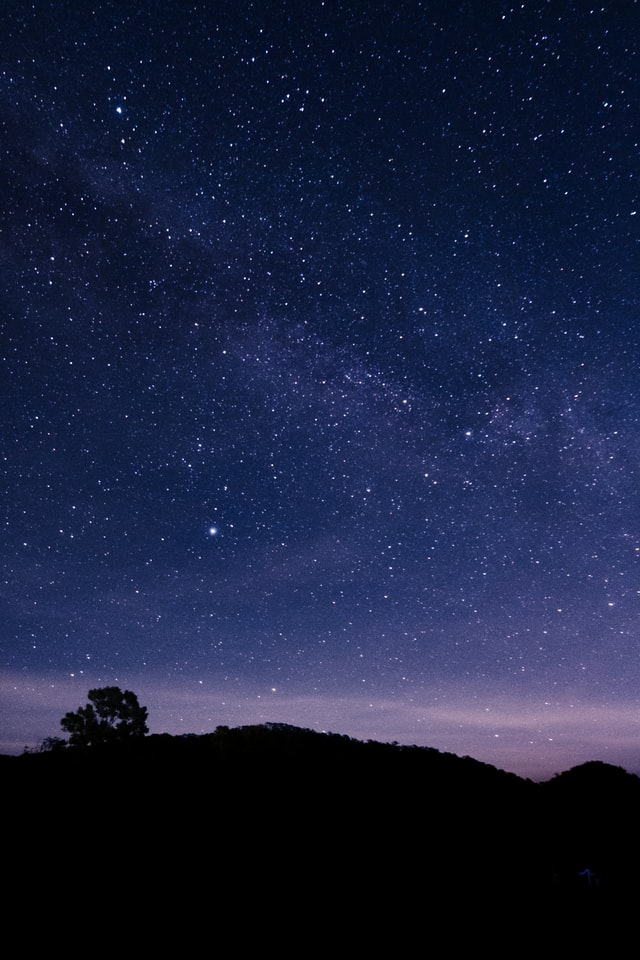


Размер кластера: 197


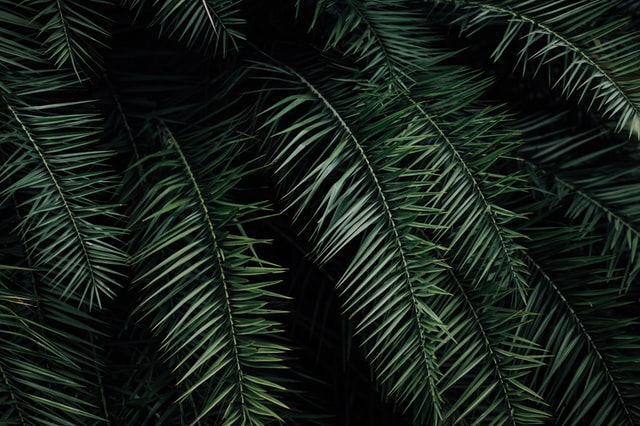

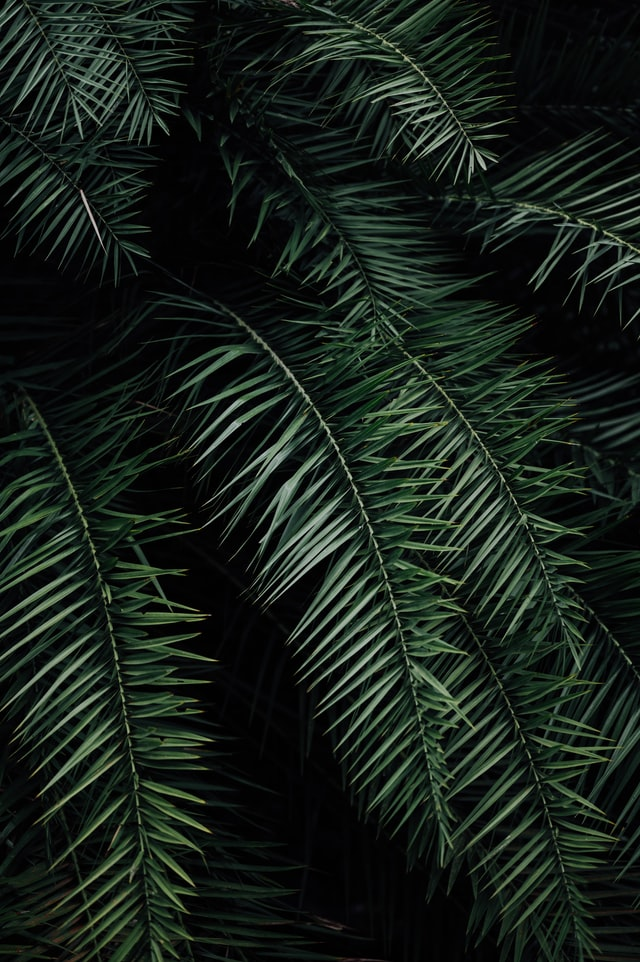

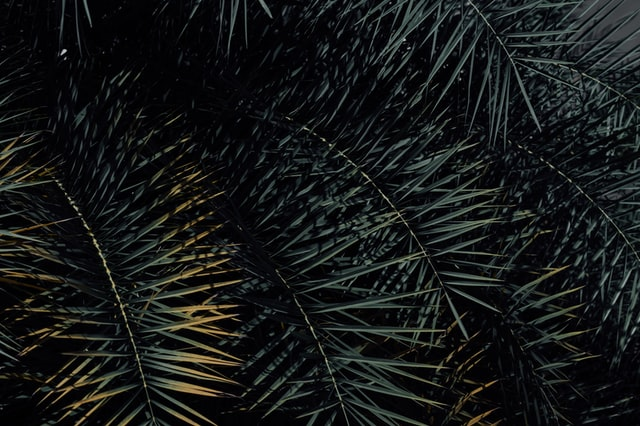


Размер кластера: 147


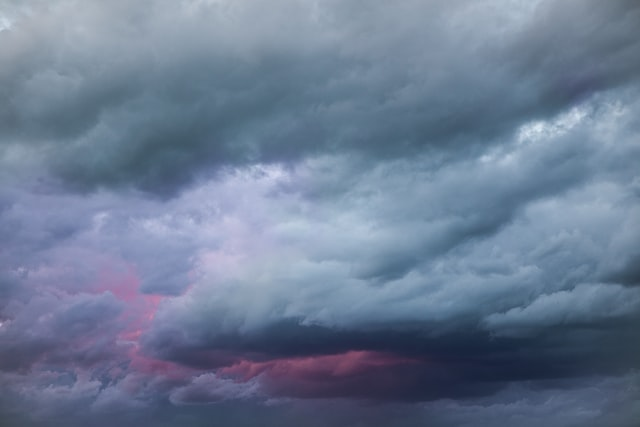

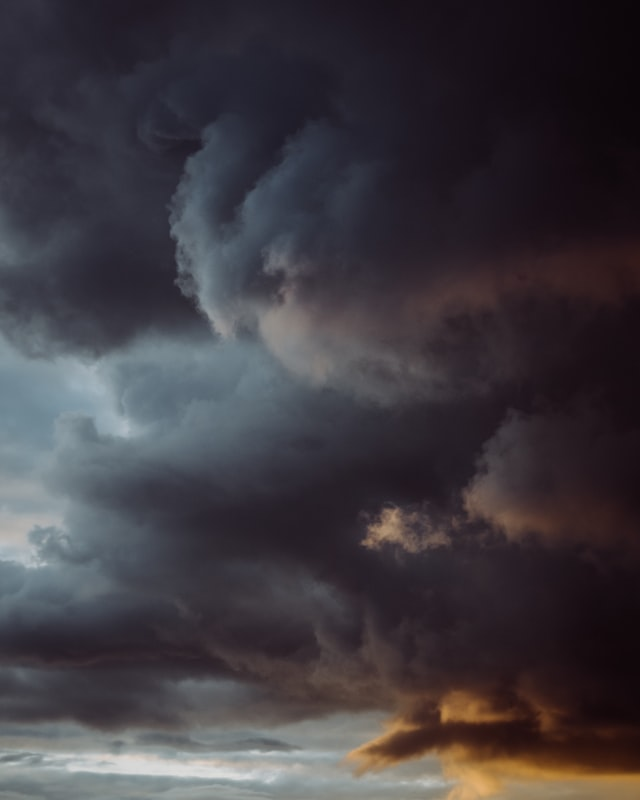

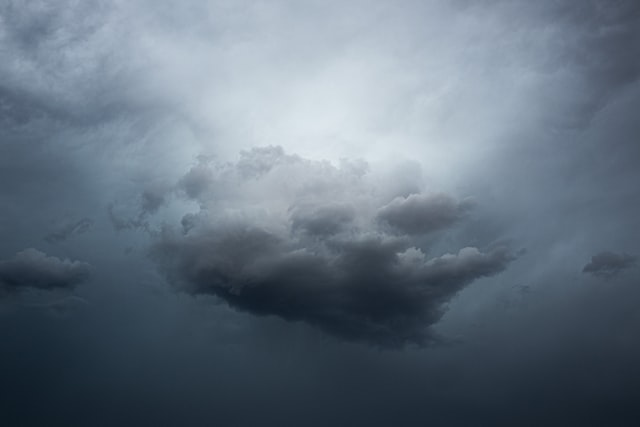


Размер кластера: 119


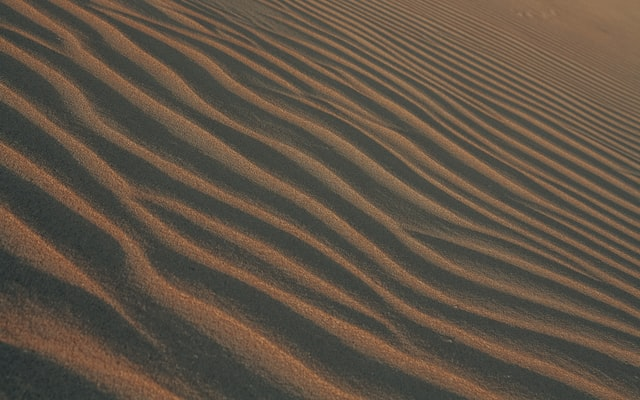

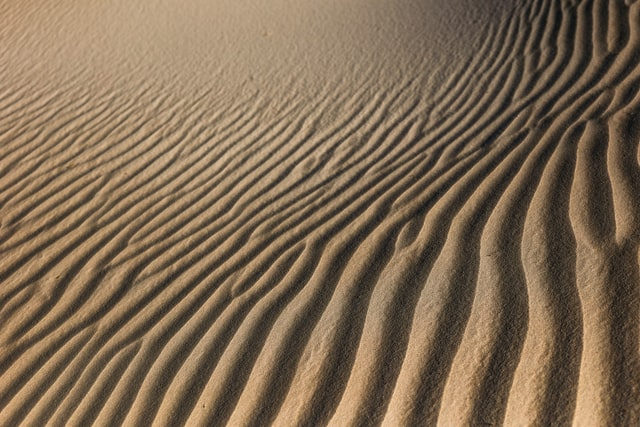

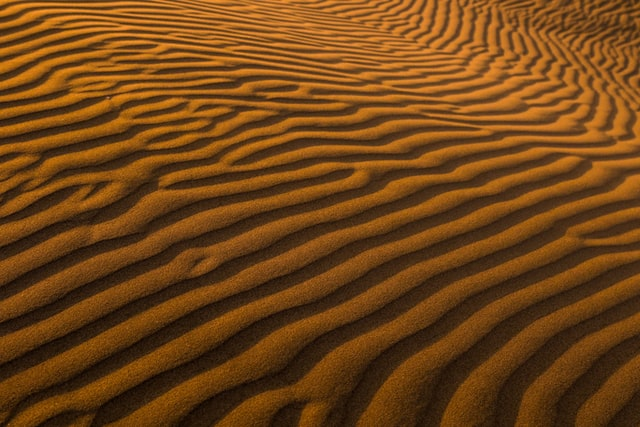


Размер кластера: 115


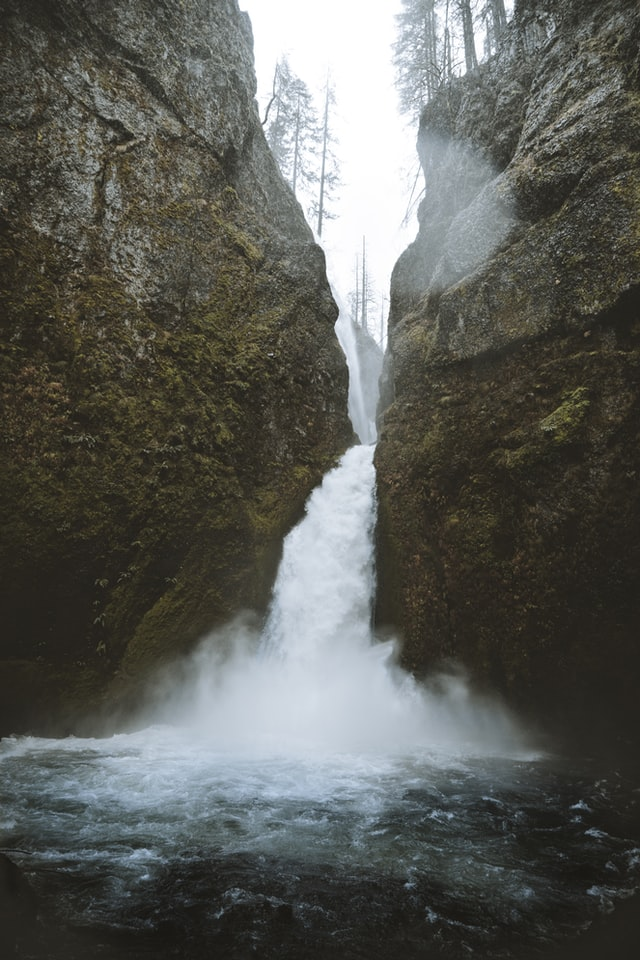

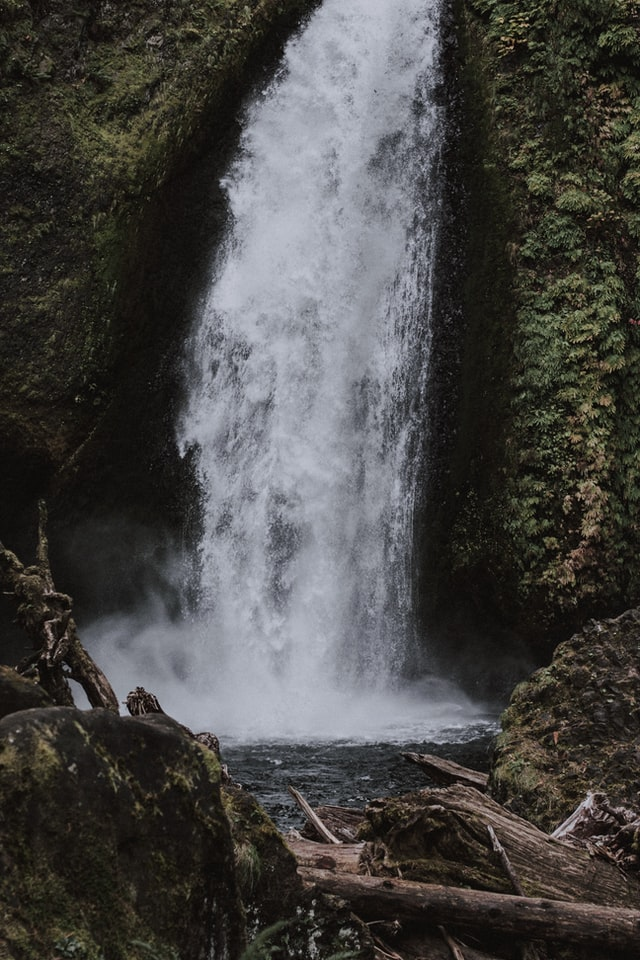

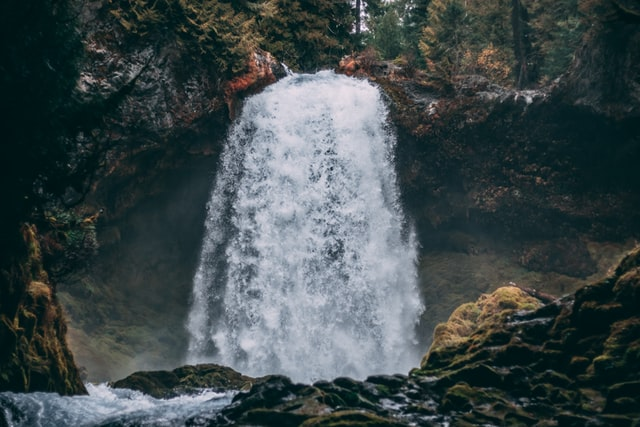


Размер кластера: 115


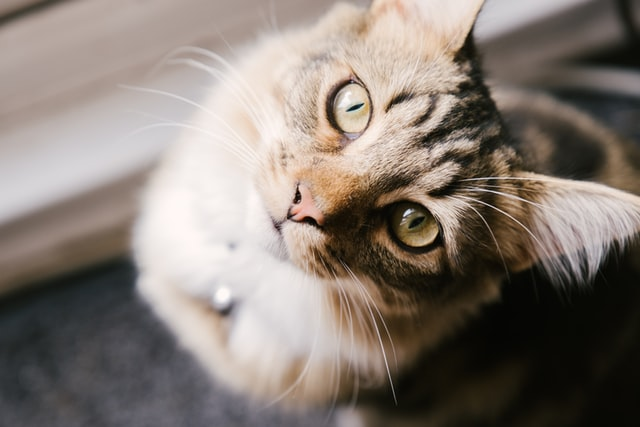

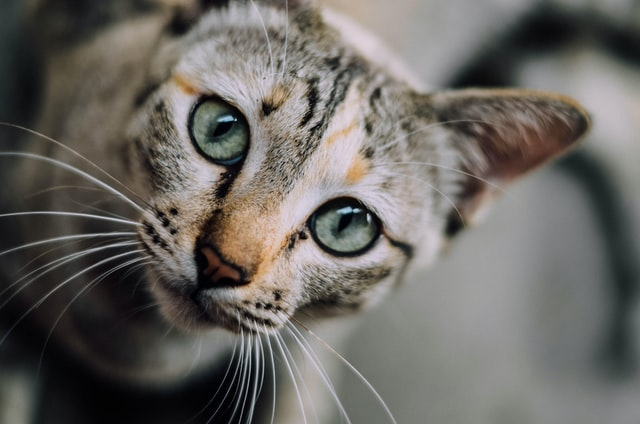

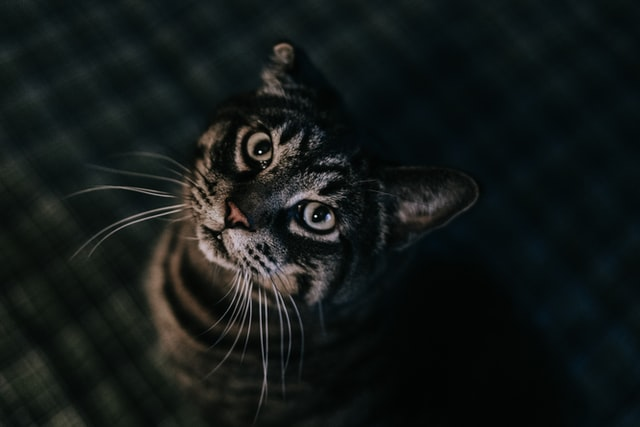


Размер кластера: 101


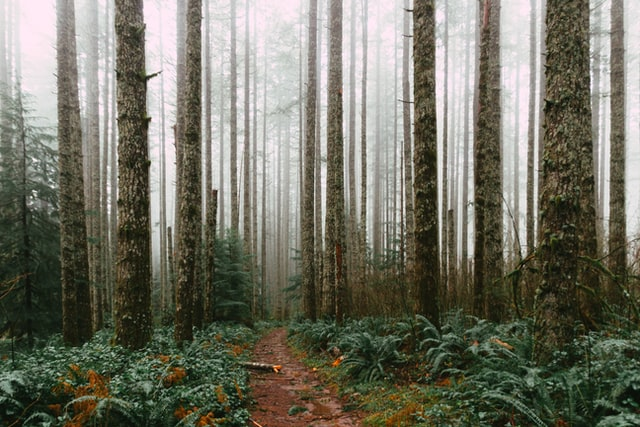

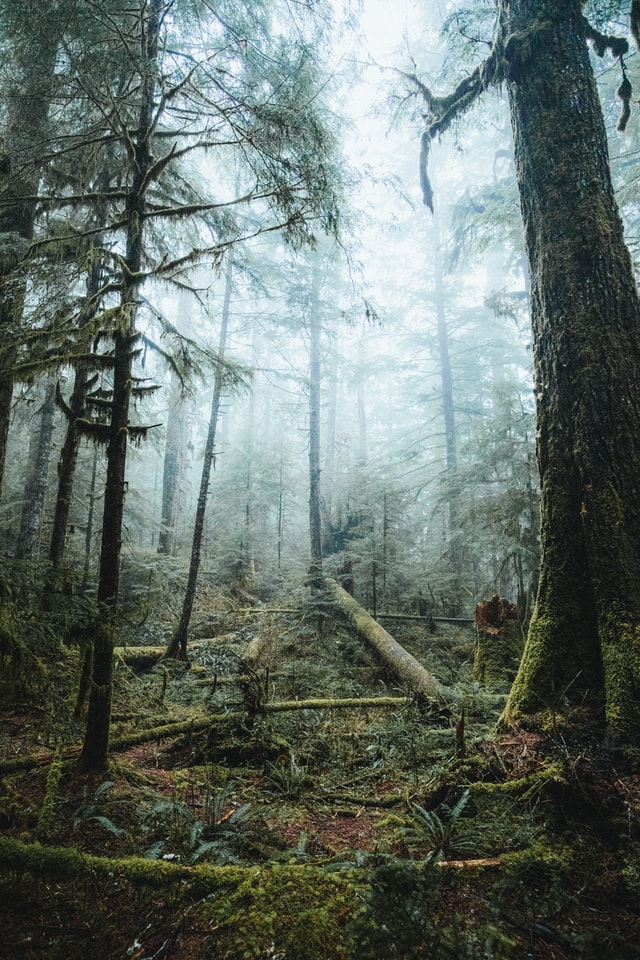

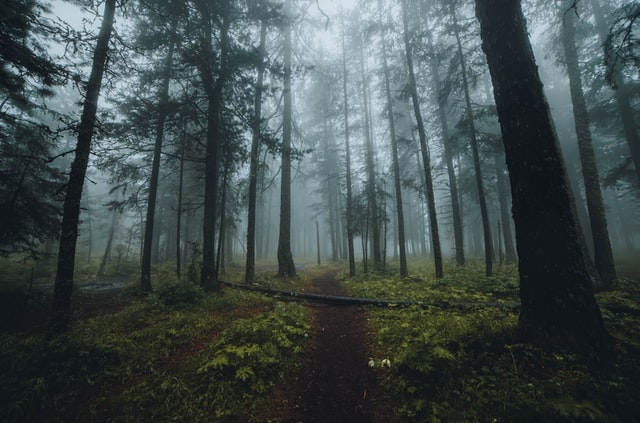

In [7]:
# Выводим размеры 10 самых крупных кластеров
for cluster in clusters[0:10]:
    print("\nРазмер кластера:", len(cluster))

    # Выводим по 3 картинки каждого класетра
    for idx in cluster[0:3]:
        display(IPImage(img_names[idx], width=200))